In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
fraud_data = pd.read_csv("fraud_detection.csv")

print("Dataset loaded successfully!")
print(fraud_data.head())
print("\nShape:", fraud_data.shape)

Dataset loaded successfully!
   TransactionAmount  TransactionFrequency  International  AccountAge  Fraud
0                100                     2              0          60      0
1               2500                    15              1           5      1
2                 50                     1              0         120      0
3               5000                    20              1           3      1
4                120                     3              0          80      0

Shape: (15, 5)


In [3]:
X = fraud_data.drop("Fraud", axis=1)
y = fraud_data["Fraud"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['TransactionAmount', 'TransactionFrequency', 'International', 'AccountAge']

Target:
Fraud


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 10
Testing samples: 5


In [5]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 1.0


In [6]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 1.0


In [7]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [rf_accuracy, xgb_accuracy]
})

print(comparison)

           Model  Accuracy
0  Random Forest       1.0
1        XGBoost       1.0


In [8]:
print("===== Random Forest =====")
print(classification_report(y_test, rf_pred, zero_division=0))

print("\n===== XGBoost =====")
print(classification_report(y_test, xgb_pred, zero_division=0))

===== Random Forest =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5


===== XGBoost =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



In [9]:
rf_train_pred = rf_model.predict(X_train)
xgb_train_pred = xgb_model.predict(X_train)

rf_train_accuracy = accuracy_score(y_train, rf_train_pred)
xgb_train_accuracy = accuracy_score(y_train, xgb_train_pred)

print("Random Forest Training Accuracy:", rf_train_accuracy)
print("Random Forest Testing Accuracy:", rf_accuracy)

print("\nXGBoost Training Accuracy:", xgb_train_accuracy)
print("XGBoost Testing Accuracy:", xgb_accuracy)

print("\nRandom Forest Accuracy Gap:",
      rf_train_accuracy - rf_accuracy)

print("XGBoost Accuracy Gap:",
      xgb_train_accuracy - xgb_accuracy)

Random Forest Training Accuracy: 1.0
Random Forest Testing Accuracy: 1.0

XGBoost Training Accuracy: 1.0
XGBoost Testing Accuracy: 1.0

Random Forest Accuracy Gap: 0.0
XGBoost Accuracy Gap: 0.0


In [10]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Training Accuracy": [rf_train_accuracy, xgb_train_accuracy],
    "Testing Accuracy": [rf_accuracy, xgb_accuracy],
    "Accuracy Gap": [
        rf_train_accuracy - rf_accuracy,
        xgb_train_accuracy - xgb_accuracy
    ]
})

print(comparison)

comparison.to_csv(
    "boosting_performance_comparison.csv",
    index=False
)

print("\nPerformance comparison saved successfully!")

           Model  Training Accuracy  Testing Accuracy  Accuracy Gap
0  Random Forest                1.0               1.0           0.0
1        XGBoost                1.0               1.0           0.0

Performance comparison saved successfully!


In [11]:
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

print(xgb_importance)

                Feature  Importance
0     TransactionAmount         1.0
1  TransactionFrequency         0.0
2         International         0.0
3            AccountAge         0.0


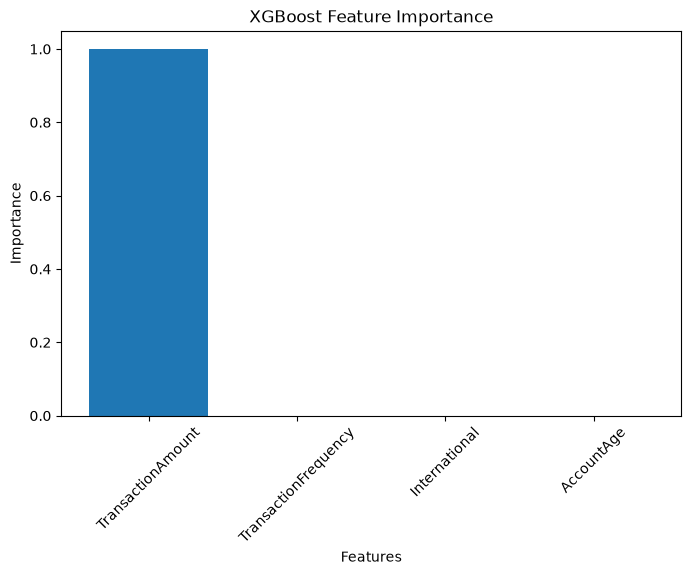

In [12]:
plt.figure(figsize=(8, 5))

plt.bar(
    xgb_importance["Feature"],
    xgb_importance["Importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("XGBoost Feature Importance")
plt.xticks(rotation=45)

plt.show()

In [14]:
xgb_importance.to_csv(
    "xgboost_feature_importance.csv",
    index=False
)

print("XGBoost feature importance report saved successfully!")

XGBoost feature importance report saved successfully!


## Boosting Advantages and Tradeoffs

### Advantages
- Builds models sequentially to improve prediction errors.
- Can achieve strong predictive performance.
- Captures complex relationships in data.
- Provides feature importance for model interpretation.
- XGBoost includes regularization to help control overfitting.

### Tradeoffs
- Training can be more computationally expensive than a single Decision Tree.
- Requires tuning parameters such as learning rate, tree depth, and number of estimators.
- Models can be harder to interpret than a single Decision Tree.
- Poor parameter choices can still lead to overfitting.

## Conclusion

In this project, I compared Random Forest with XGBoost for fraud detection. XGBoost uses boosting, where trees are built sequentially to improve previous errors. The comparison helped me understand how advanced ensemble methods can improve predictive modeling and why model evaluation should consider more than accuracy alone.